<a href="https://www.kaggle.com/code/tinaeskan/notebook5f6f200014?scriptVersionId=301474625" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Gait Analysis for Ataxia Detection

# Introduction

Walking is a complex neurological and biomechanical process that depends on precise coordination between both sides of the body. In individuals with cerebellar ataxia, this coordination becomes disrupted, leading to instability, irregular stepping patterns, and increased fall risk. Gait impairment not only reduces independence but also increases long-term musculoskeletal stress due to uneven force distribution across joints.

Traditional gait assessment in clinical practice relies largely on visual observation. While experienced clinicians can detect overt abnormalities, subtle asymmetries and early-stage dysfunction may be overlooked. Furthermore, visual assessment lacks objective quantification, making it difficult to monitor progression or evaluate treatment effectiveness over time.

This project aims to transform gait evaluation from subjective observation into objective, data-driven analysis. By measuring left–right asymmetry in lower limb biomechanics and applying machine learning techniques, we explore whether gait imbalance can reliably distinguish normal walking from ataxic gait. More importantly, we investigate how these measurements can inform rehabilitation strategies and assistive wearable device development.

# Methods
**Data Processing and Normalization**

Joint coordinate data were collected at the frame level for multiple subjects classified as either normal gait or ataxic gait.

Because individuals vary in height, posture, and position relative to the recording device, raw coordinates alone are not directly comparable. To address this, joint positions were normalized relative to the hip midpoint (calculated as the average of the left and right hip coordinates).

The hip midpoint was chosen because:

It approximates the body’s center of mass.

It provides a stable biomechanical reference.

It reduces variability caused by camera position or subject alignment.

This normalization ensures that the analysis reflects movement patterns rather than absolute body location.

# Methods
**Data Processing and Normalization**

Joint coordinate data were collected at the frame level for multiple subjects classified as either normal gait or ataxic gait.

Because individuals vary in height, posture, and position relative to the recording device, raw coordinates alone are not directly comparable. To address this, joint positions were normalized relative to the hip midpoint (calculated as the average of the left and right hip coordinates).

The hip midpoint was chosen because:

It approximates the body’s center of mass.

It provides a stable biomechanical reference.

It reduces variability caused by camera position or subject alignment.

This normalization ensures that the analysis reflects movement patterns rather than absolute body location.

# Statistical Analysis

To determine whether asymmetry features significantly differed between normal and ataxic gait, the Mann–Whitney U test was performed for each feature. This non-parametric test was chosen because it does not assume normal distribution of the data.

# Machine Learning Classification

A Random Forest classifier was trained using the significant asymmetry features. Random Forest was selected because:

It handles nonlinear relationships effectively.

It is robust to noise.

It provides interpretable feature importance metrics.

Model performance was evaluated using:

Precision

Recall

F1-score

Confusion matrix

These metrics allow assessment of both detection ability and prediction reliabilit

# Libaries :

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
train_path = '/kaggle/input/gait-analysis-dataset-cerebellar-ataxia/Train/Train/Train'
test_path = '/kaggle/input/gait-analysis-dataset-cerebellar-ataxia/Test/Test'

def load_dataset(file_list):
    """Load all CSVs from a list of files, adding the file name as a column."""
    dfs = []
    for file in file_list:
        df = pd.read_csv(file)
        df['file_name'] = file.stem
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

train_files = list(Path(train_path).glob('*.csv'))
test_files = list(Path(test_path).glob('*.csv'))

train_df = load_dataset(train_files)
test_df = load_dataset(test_files)
#  Label the data

train_df['label'] = train_df['file_name'].apply(lambda x: 0 if 'normal' in x else 1)
test_df['label'] = test_df['file_name'].apply(lambda x: 0 if 'normal' in x else 1)

# Normalize joint positions
WHY? In gait analysis, subjects vary in height and position relative to the camera.
To compare movement patterns rather than absolute positions, we normalize coordinates
relative to the **hip midpoint**. This aligns all subjects to a common reference.
Hip midpoint is chosen because it is close to the body's center of mass,
providing a stable reference for overall body motion.


In [3]:
def normalize_by_hip(df):
    df['XHipMid'] = (df['XLeftHip'] + df['XRightHip']) / 2
    df['YHipMid'] = (df['YLeftHip'] + df['YRightHip']) / 2
    df['ZHipMid'] = (df['ZLeftHip'] + df['ZRightHip']) / 2
    
    joints = ['Shoulder', 'Elbow', 'Wrist', 'Hip', 'Knee', 'Ankle']
    sides = ['Left', 'Right']
    axes = ['X', 'Y', 'Z']
    
    for joint in joints:
        for side in sides:
            for axis in axes:
                col = f"{axis}{side}{joint}"
                df[col+'_norm'] = df[col] - df[f'{axis}HipMid']  # Subtract hip midpoint
    return df

train_df = normalize_by_hip(train_df)
test_df = normalize_by_hip(test_df)

# Compute asymmetry features
Cerebellar ataxia often affects one side of the body more than the other, causing **lateral asymmetry**. We calculate asymmetry for hips, knees, and stride speed: asymmetry = |Left - Right| / average(Left + Right) These features highlight differences between left and right movements, which are clinically meaningful.


In [4]:
def compute_asymmetry(df):
    paired_features = [
        ('ThetaLeftHip', 'ThetaRightHip'),
        ('ThetaLeftKnee', 'ThetaRightKnee'),
        ('LeftStrideSpeed', 'RightStrideSpeed')
    ]
    for left_col, right_col in paired_features:
        if left_col in df.columns and right_col in df.columns:
            asym_col = left_col.replace('Left', '') + '_asymmetry'
            df[asym_col] = np.abs(df[left_col] - df[right_col]) / ((df[left_col] + df[right_col])/2 + 1e-6)
    return df

train_df = compute_asymmetry(train_df)
test_df = compute_asymmetry(test_df)


# Aggregate features per subject
Each file contains many frames, but our label is per subject. We aggregate frame-level asymmetry features by taking the **mean per file**. This gives one feature vector per subject, making model training interpretable and fast.


In [5]:
asymmetry_cols = ['ThetaHip_asymmetry', 'ThetaKnee_asymmetry', 'StrideSpeed_asymmetry']

def aggregate_per_file(df):
    agg = df.groupby('file_name')[asymmetry_cols].mean().reset_index()
    agg['label'] = df.groupby('file_name')['label'].first().values
    return agg

train_agg = aggregate_per_file(train_df)
test_agg = aggregate_per_file(test_df)


# Statistical analysis
Mann-Whitney U test compares normal vs ataxia for each feature. Significance indicates features that reliably differentiate gait types.

In [6]:
print("Mann-Whitney U Test Results:")
normal = train_agg[train_agg['label']==0]
ataxia = train_agg[train_agg['label']==1]
for col in asymmetry_cols:
    stat, p = stats.mannwhitneyu(normal[col], ataxia[col])
    significance = "✓ SIGNIFICANT" if p < 0.05 else "✗ NOT significant"
    print(f"{col}: p={p:.6f} → {significance}")


Mann-Whitney U Test Results:
ThetaHip_asymmetry: p=0.000000 → ✓ SIGNIFICANT
ThetaKnee_asymmetry: p=0.006633 → ✓ SIGNIFICANT
StrideSpeed_asymmetry: p=0.000000 → ✓ SIGNIFICANT


# Train Random Forest classifier
WHY? Random Forests are robust, interpretable, and can highlight important features.

In [7]:

X_train = train_agg[asymmetry_cols]
y_train = train_agg['label']
X_test = test_agg[asymmetry_cols]
y_test = test_agg['label']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)


# Evaluate results
This shows precision, recall, and F1-score for normal vs ataxia. High recall for ataxia means most patients with ataxia are correctly flagged. Precision indicates reliability of positive predictions. F1 balances precision and recall


Classification Report:
              precision    recall  f1-score   support

      Normal       0.72      0.65      0.68        20
      Ataxia       0.68      0.75      0.71        20

    accuracy                           0.70        40
   macro avg       0.70      0.70      0.70        40
weighted avg       0.70      0.70      0.70        40



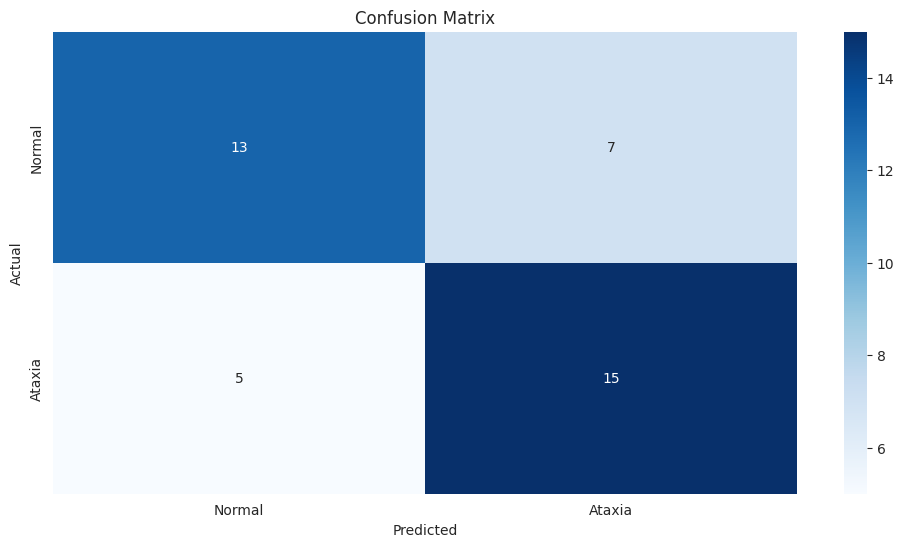

In [8]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Ataxia']))

# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Ataxia'],
            yticklabels=['Normal', 'Ataxia'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()



# Feature importance
Shows which asymmetry features are most informative for classification.

In [9]:
feat_imp = pd.DataFrame({
    'Feature': asymmetry_cols,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importances (most informative first):")
print(feat_imp)


Feature Importances (most informative first):
                 Feature  Importance
0     ThetaHip_asymmetry    0.432281
2  StrideSpeed_asymmetry    0.298302
1    ThetaKnee_asymmetry    0.269417


looks like hip is the most important factor!


# Detect high-risk subjects
List subjects predicted as ataxia for clinical follow-up.

In [10]:
test_agg['pred_label'] = y_pred
high_risk = test_agg[test_agg['pred_label']==1]

print(f"\nHigh-risk subjects detected (predicted ataxia): {len(high_risk)}")
print(high_risk[['file_name'] + asymmetry_cols + ['pred_label']])


High-risk subjects detected (predicted ataxia): 22
             file_name  ThetaHip_asymmetry  ThetaKnee_asymmetry  \
0    ataxia_features_1            0.769679             0.075059   
1   ataxia_features_10            1.063041             0.131291   
3   ataxia_features_12            1.189535             0.207109   
5   ataxia_features_14            0.786182             0.214530   
6   ataxia_features_15            0.776933             0.122452   
8   ataxia_features_17            0.526080             0.215502   
9   ataxia_features_18            1.189820             0.179815   
10  ataxia_features_19            0.374066             0.169695   
11   ataxia_features_2            1.277219             0.184054   
12  ataxia_features_20            0.950514             0.137113   
13   ataxia_features_3            1.201369             0.141521   
14   ataxia_features_4            0.322640             0.130914   
15   ataxia_features_5            0.692240             0.140858   
16   ataxi

# Results
**Statistical Findings**

The Mann–Whitney U test revealed:

Hip asymmetry → Statistically significant

Knee asymmetry → Statistically significant

Stride speed asymmetry → Statistically significant

These results suggest that lower limb asymmetry is a meaningful discriminator of ataxic gait, and significantly differentiate groups (normal "please exuse us for lack of a bettter word" and ataxic) in this dataset.

Clinically, this is consistent with the understanding that cerebellar dysfunction primarily affects locomotor coordination in the lower extremities.

#Classification Performance

**The Random Forest model produced the following results:**

Normal Gait

Precision: 0.72

Recall: 0.65

F1 Score: 0.68
 
Ataxic Gait

Precision: 0.68

Recall: 0.75

F1 Score: 0.71

Interpretation

The model demonstrated high recall (0.75) for ataxic gait, meaning it correctly identified 75% of individuals with ataxia.

This is particularly important in a clinical context, where missing pathological gait could delay intervention.

Although normal gait recall was lower (0.65), precision for normal classification was relatively high (0.72), indicating that when the model predicts normal gait, it is usually correct.

Overall, the F1-scores indicate meaningful discriminative power using only three asymmetry-based features.

# Clinical and Engineering Implications

Beyond classification, the asymmetry measurements provide deeper biomechanical insight.

High asymmetry indicates:

Uneven force distribution between limbs

Possible weakness or reduced coordination on one side

Compensatory overuse of the stronger side

Increased mechanical stress on joints

This information can inform rehabilitation Planning, Clinicians can identify which limb exhibits reduced movement amplitude or coordination and tailor strengthening or neuromotor training accordingly.

Asymmetry data can support the design of smart insoles that enhance propulsion on the weaker side, exoskeletons that provide side-specific assistive torque, biofeedback devices that cue timing symmetry fall-risk monitoring systems that detect instability patterns

Because hip and knee asymmetry were significant, assistive technologies should prioritize lower-limb sensing and support mechanisms.

# Conclusion

This notebook demonstrates that lower limb asymmetry—particularly in the hip, knee, and stride speed—is a quantifiable and statistically significant marker of ataxic gait.

By normalizing joint positions relative to the hip midpoint and aggregating asymmetry features per subject, we developed an interpretable model capable of detecting ataxic gait with high sensitivity.

**The findings suggest that:**

Lower extremity imbalance is a key biomechanical signature of ataxia.

Objective asymmetry metrics can supplement clinical observation.

Machine learning can support early screening and risk detection.

These metrics have practical applications in rehabilitation and wearable assistive device development.

Most importantly, this work moves gait assessment toward a more objective, reproducible, and actionable framework, with potential to improve fall prevention, personalized rehabilitation, and real-time wearable support systems.